In [75]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

In [76]:
def use_elsarticle_12pt_no_tex():
    base = 12.0  # match \normalsize
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "TeX Gyre Termes", "DejaVu Serif"],
        "mathtext.fontset": "stix",

        "font.size": base * 1,             
        "axes.labelsize": base*1.3,        
        "axes.titlesize": base*1.2,    
        "xtick.labelsize": base*1,  
        "ytick.labelsize": base*1,  
        "legend.fontsize": base*0.83,  
        "legend.title_fontsize": base, 


        "svg.fonttype": "none",
        "pdf.fonttype": 42, "ps.fonttype": 42,
        "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    })

use_elsarticle_12pt_no_tex()

In [77]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

PROJECT_ROOT


WindowsPath('c:/Users/tm1621/Desktop/market-data-quality-pipeline')

In [78]:
# Load raw sample data
raw_path = PROJECT_ROOT / "data" / "raw" / "sample_taq.csv"

if not raw_path.exists():
    from mdq.generate_sample_data import build_sample_taq
    
    raw_path.parent.mkdir(parents=True, exist_ok=True)
    build_sample_taq(days=5).to_csv(raw_path, index=False)

raw = pd.read_csv(raw_path)
raw.head(10)

,event_ts,symbol,event_type,exchange,trade_price,trade_size,bid_price,ask_price,bid_size,ask_size
0,2026-05-11T13:30:00+00:00,AAPL,QUOTE,XNAS,NaN,NaN,179.99,180.01,100.0,120.0
1,2026-05-11T13:30:00.250000+00:00,AAPL,TRADE,XNAS,180.00,50.0,NaN,NaN,NaN,NaN
2,2026-05-11T13:30:01+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.00,180.02,101.0,121.0
3,2026-05-11T13:30:02+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.01,180.03,102.0,122.0
4,2026-05-11T13:30:03+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.02,180.04,103.0,123.0
5,2026-05-11T13:30:03.250000+00:00,AAPL,TRADE,XNAS,180.03,53.0,NaN,NaN,NaN,NaN
6,2026-05-11T13:30:04+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.03,180.05,104.0,124.0
7,2026-05-11T13:30:05+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.04,180.06,105.0,125.0
8,2026-05-11T13:30:06+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.05,180.07,106.0,126.0
9,2026-05-11T13:30:06.250000+00:00,AAPL,TRADE,XNAS,180.06,56.0,NaN,NaN,NaN,NaN


In [79]:
# Import pipeline functions
from mdq.pipeline import (
    load_raw_market_data,
    normalize_market_data,
    clean_for_research,
    write_outputs,
    run_pipeline,
)

from mdq.quality_checks import run_quality_checks

In [80]:
raw = load_raw_market_data(raw_path)
normalized = normalize_market_data(raw)

normalized.head()

,event_ts,symbol,event_type,exchange,trade_price,trade_size,bid_price,ask_price,bid_size,ask_size
0,2026-05-11 13:30:00+00:00,AAPL,QUOTE,XNAS,NaN,NaN,179.99,180.01,100.0,120.0
1,2026-05-11 13:30:00.250000+00:00,AAPL,TRADE,XNAS,180.0,50.0,NaN,NaN,NaN,NaN
2,2026-05-11 13:30:01+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.00,180.02,101.0,121.0
3,2026-05-11 13:30:02+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.01,180.03,102.0,122.0
4,2026-05-11 13:30:03+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.02,180.04,103.0,123.0


In [81]:
problems = run_quality_checks(normalized)

for problem in problems:
    print(f"{problem.check_name} | {problem.severity} | {problem.row_count} rows")
    print(problem.message)
    print()

duplicate_events | medium | 2 rows
Duplicate market data events detected.

non_positive_prices | critical | 1 rows
Non-positive prices detected.

crossed_quotes | high | 1 rows
Quote rows where bid price is greater than ask price.

abnormal_trade_returns | medium | 4 rows
Trade-to-trade absolute return exceeded 500 bps.



In [82]:
problems_df = pd.DataFrame([
    {
        "check_name": problem.check_name,
        "severity": problem.severity,
        "row_count": problem.row_count,
        "message": problem.message,
    }
    for problem in problems
])

problems_df

,check_name,severity,row_count,message
0,duplicate_events,medium,2,Duplicate market data events detected.
1,non_positive_prices,critical,1,Non-positive prices detected.
2,crossed_quotes,high,1,Quote rows where bid price is greater than ask...
3,abnormal_trade_returns,medium,4,Trade-to-trade absolute return exceeded 500 bps.


In [83]:
clean = clean_for_research(normalized)

output_dir = PROJECT_ROOT / "data" / "processed"
report_dir = PROJECT_ROOT / "reports"

write_outputs(clean, problems, output_dir, report_dir)

clean.head()

,event_ts,symbol,event_type,exchange,trade_price,trade_size,bid_price,ask_price,bid_size,ask_size,event_date
0,2026-05-11 13:30:00+00:00,AAPL,QUOTE,XNAS,NaN,NaN,179.99,180.01,100.0,120.0,2026-05-11
1,2026-05-11 13:30:00.250000+00:00,AAPL,TRADE,XNAS,180.0,50.0,NaN,NaN,NaN,NaN,2026-05-11
2,2026-05-11 13:30:01+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.00,180.02,101.0,121.0,2026-05-11
3,2026-05-11 13:30:02+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.01,180.03,102.0,122.0,2026-05-11
4,2026-05-11 13:30:03+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.02,180.04,103.0,123.0,2026-05-11


In [84]:
report_path = PROJECT_ROOT / "reports" / "data_quality_report.md"

print(report_path.read_text())

# Data Quality Report

Rows processed: 343
Checks failed: 4

## Failed checks

### duplicate_events

- Severity: `medium`
- Rows affected: `2`
- Message: Duplicate market data events detected.

Sample rows:

```json
[
  {
    "event_ts": "2026-05-11 13:30:02+00:00",
    "symbol": "AAPL",
    "event_type": "QUOTE",
    "exchange": "XNAS",
    "trade_price": null,
    "trade_size": null,
    "bid_price": 180.01,
    "ask_price": 180.03,
    "bid_size": 102.0,
    "ask_size": 122.0
  },
  {
    "event_ts": "2026-05-11 13:30:02+00:00",
    "symbol": "AAPL",
    "event_type": "QUOTE",
    "exchange": "XNAS",
    "trade_price": null,
    "trade_size": null,
    "bid_price": 180.01,
    "ask_price": 180.03,
    "bid_size": 102.0,
    "ask_size": 122.0
  }
]
```

### non_positive_prices

- Severity: `critical`
- Rows affected: `1`
- Message: Non-positive prices detected.

Sample rows:

```json
[
  {
    "event_ts": "2026-05-12 13:30:31+00:00",
    "symbol": "MSFT",
    "event_type": "TRADE",
 

### **Analytics**

In [85]:
fig_dir = PROJECT_ROOT / "reports" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

In [86]:
events = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "market_events.csv")
events["event_ts"] = pd.to_datetime(
    events["event_ts"],
    format="ISO8601",
    utc=True,
 )
events["event_date"] = events["event_ts"].dt.date

events.head()

,event_ts,symbol,event_type,exchange,trade_price,trade_size,bid_price,ask_price,bid_size,ask_size,event_date
0,2026-05-11 13:30:00+00:00,AAPL,QUOTE,XNAS,NaN,NaN,179.99,180.01,100.0,120.0,2026-05-11
1,2026-05-11 13:30:00.250000+00:00,AAPL,TRADE,XNAS,180.0,50.0,NaN,NaN,NaN,NaN,2026-05-11
2,2026-05-11 13:30:01+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.00,180.02,101.0,121.0,2026-05-11
3,2026-05-11 13:30:02+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.01,180.03,102.0,122.0,2026-05-11
4,2026-05-11 13:30:03+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.02,180.04,103.0,123.0,2026-05-11


In [87]:
valid_events = events.copy()

# Remove non-positive trade prices
valid_events = valid_events[
    ~(
        (valid_events["event_type"] == "TRADE")
        & (valid_events["trade_price"].notna())
        & (valid_events["trade_price"] <= 0)
    )
]

# Remove crossed quotes
valid_events = valid_events[
    ~(
        (valid_events["event_type"] == "QUOTE")
        & (valid_events["bid_price"].notna())
        & (valid_events["ask_price"].notna())
        & (valid_events["bid_price"] > valid_events["ask_price"])
    )
]


valid_events.to_csv(PROJECT_ROOT / "data" / "processed" / "valid_market_events.csv", index=False)
valid_events.head()

,event_ts,symbol,event_type,exchange,trade_price,trade_size,bid_price,ask_price,bid_size,ask_size,event_date
0,2026-05-11 13:30:00+00:00,AAPL,QUOTE,XNAS,NaN,NaN,179.99,180.01,100.0,120.0,2026-05-11
1,2026-05-11 13:30:00.250000+00:00,AAPL,TRADE,XNAS,180.0,50.0,NaN,NaN,NaN,NaN,2026-05-11
2,2026-05-11 13:30:01+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.00,180.02,101.0,121.0,2026-05-11
3,2026-05-11 13:30:02+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.01,180.03,102.0,122.0,2026-05-11
4,2026-05-11 13:30:03+00:00,AAPL,QUOTE,XNAS,NaN,NaN,180.02,180.04,103.0,123.0,2026-05-11


In [88]:
quotes = valid_events[valid_events["event_type"] == "QUOTE"].copy()

quotes["mid_price"] = (quotes["bid_price"] + quotes["ask_price"]) / 2
quotes["spread"] = quotes["ask_price"] - quotes["bid_price"]
quotes["spread_bps"] = 10_000 * quotes["spread"] / quotes["mid_price"]

quotes[["event_ts", "symbol", "bid_price", "ask_price", "mid_price", "spread_bps"]].head(5)

,event_ts,symbol,bid_price,ask_price,mid_price,spread_bps
0,2026-05-11 13:30:00+00:00,AAPL,179.99,180.01,180.00,1.111111
2,2026-05-11 13:30:01+00:00,AAPL,180.00,180.02,180.01,1.111049
3,2026-05-11 13:30:02+00:00,AAPL,180.01,180.03,180.02,1.110988
4,2026-05-11 13:30:03+00:00,AAPL,180.02,180.04,180.03,1.110926
6,2026-05-11 13:30:04+00:00,AAPL,180.03,180.05,180.04,1.110864


In [89]:
trades = valid_events[valid_events["event_type"] == "TRADE"].copy()
trades = trades.sort_values(["symbol", "event_ts"])

trades["prev_trade_price"] = trades.groupby("symbol")["trade_price"].shift(1)
trades["return_bps"] = 10_000 * (trades["trade_price"] / trades["prev_trade_price"] - 1)

trades[["event_ts", "symbol", "trade_price", "prev_trade_price", "return_bps"]].head(5)

,event_ts,symbol,trade_price,prev_trade_price,return_bps
1,2026-05-11 13:30:00.250000+00:00,AAPL,180.00,NaN,NaN
5,2026-05-11 13:30:03.250000+00:00,AAPL,180.03,180.00,1.666667
9,2026-05-11 13:30:06.250000+00:00,AAPL,180.06,180.03,1.666389
13,2026-05-11 13:30:09.250000+00:00,AAPL,180.09,180.06,1.666111
17,2026-05-11 13:30:12.250000+00:00,AAPL,180.12,180.09,1.665834


In [90]:
daily_quote_summary = (
    quotes
    .groupby(["event_date", "symbol"])
    .agg(
        quote_count=("event_ts", "count"),
        avg_spread_bps=("spread_bps", "mean"),
        max_spread_bps=("spread_bps", "max"),
        avg_mid_price=("mid_price", "mean"),
    )
    .reset_index()
)


daily_trade_summary = (
    trades
    .groupby(["event_date", "symbol"])
    .agg(
        trade_count=("event_ts", "count"),
        avg_trade_price=("trade_price", "mean"),
        max_abs_return_bps=("return_bps", lambda x: x.abs().max()),
    )
    .reset_index()
)

In [91]:
summary = daily_quote_summary.merge(
    daily_trade_summary,
    on=["event_date", "symbol"],
    how="outer",
)


summary.to_csv(PROJECT_ROOT / "reports" / "research_summary_by_day_symbol.csv", index=False)
summary

,event_date,symbol,quote_count,avg_spread_bps,max_spread_bps,avg_mid_price,trade_count,avg_trade_price,max_abs_return_bps
0,2026-05-11,AAPL,25,1.110371,1.111111,180.12,9,180.120,1.666667
1,2026-05-11,MSFT,25,0.908595,0.909091,220.12,9,220.120,1.363636
2,2026-05-12,AAPL,25,1.105767,1.106501,180.87,9,180.870,28.295606
3,2026-05-12,MSFT,25,0.905510,0.906002,220.87,9,220.870,23.156556
4,2026-05-13,AAPL,25,1.101200,1.101928,181.62,10,188.458,3755.915043
5,2026-05-13,MSFT,25,0.902446,0.902935,221.62,9,221.620,23.077967
6,2026-05-14,AAPL,25,1.096672,1.097394,182.37,9,182.370,2710.000000
7,2026-05-14,MSFT,25,0.899402,0.899888,222.37,9,222.370,22.999910
8,2026-05-15,AAPL,25,1.092180,1.092896,183.12,9,183.120,27.946737
9,2026-05-15,MSFT,25,0.896379,0.896861,223.12,9,223.120,22.922379


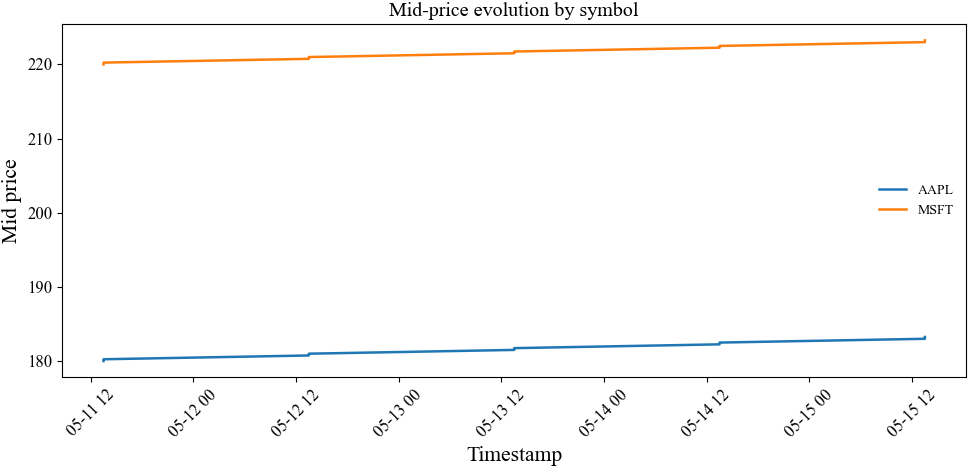

In [92]:
fig, ax = plt.subplots(figsize=(10, 5))

for symbol, grp in quotes.groupby("symbol"):
    grp = grp.sort_values("event_ts")
    ax.plot(grp["event_ts"], grp["mid_price"], linewidth=1.8, label=symbol)

ax.set_xlabel("Timestamp")
ax.set_ylabel("Mid price")
ax.set_title("Mid-price evolution by symbol")
ax.legend(frameon=False)
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(fig_dir / "mid_price_evolution.png", dpi=300)
plt.show()

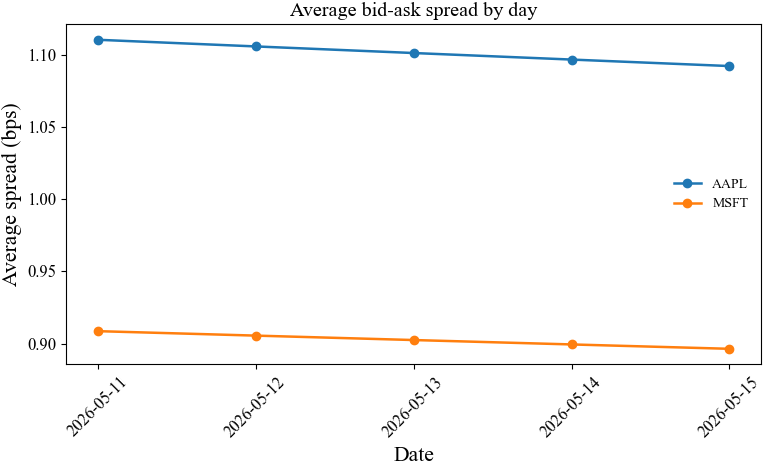

In [93]:
daily_spread = (
    quotes
    .groupby(["event_date", "symbol"])["spread_bps"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

for symbol, grp in daily_spread.groupby("symbol"):
    grp = grp.sort_values("event_date")
    ax.plot(
        grp["event_date"].astype(str),
        grp["spread_bps"],
        marker="o",
        linewidth=1.8,
        label=symbol,
    )

ax.set_xlabel("Date")
ax.set_ylabel("Average spread (bps)")
ax.set_title("Average bid-ask spread by day")
ax.legend(frameon=False)
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(fig_dir / "average_spread_bps.png", dpi=300)
plt.show()

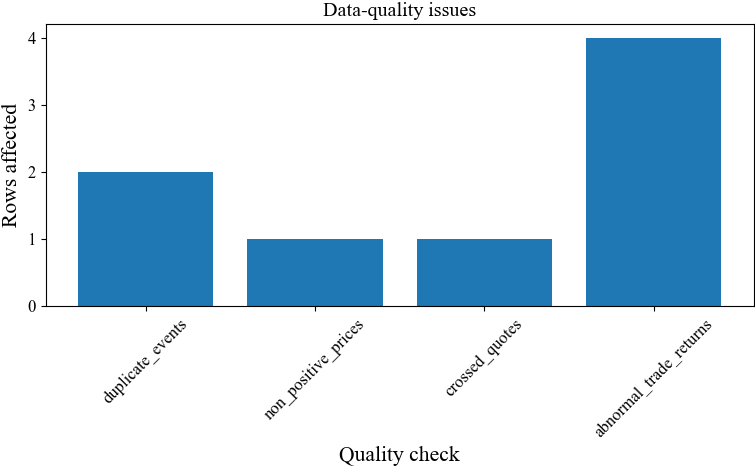

In [94]:
with open(PROJECT_ROOT / "reports" / "data_quality_summary.json", "r", encoding="utf-8") as f:
    quality_summary = json.load(f)

issues_df = pd.DataFrame(quality_summary["issues"])[["check_name", "row_count"]]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(issues_df["check_name"], issues_df["row_count"])

ax.set_xlabel("Quality check")
ax.set_ylabel("Rows affected")
ax.set_title("Data-quality issues")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(fig_dir / "quality_issue_counts.png", dpi=300)
plt.show()